<a href="https://colab.research.google.com/github/rubendariodiazvitals-crypto/EstadisticaVerano2026/blob/main/Gym_Members.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**GYM MEMBERS**

***INTRODUCCION***


**1.-¿Qué problema desea resolver el gimnasio?** Comprender mejor qué factores influyen en el gasto calórico durante una sesión de entrenamiento

**2.-¿Qué variables se analizarán?** Las base de datos fueron la edad, peso, estatura, frecuencia cardiaca, duración de la sesión, tipo de entrenamiento, frecuencia semanal y calorías quemadas

**3.-¿Por qué es útil estudiar la relación entre estas variables?**  Porque nos van a servir para ver cuales variables es la que mas aporta para quemar mas calorias

**4.-¿Cuál es el objetivo general del análisis?** Analisar las variables y tener un analisis y saber cual es la variable y que resultado daciertas variables

***METODOLOGIA***

**1.-¿Que base de datos se aplico?**

In [56]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/rubendariodiazvitals-crypto/EstadisticaVerano2026/refs/heads/main/Gym_Members/gym_members_exercise_tracking-selected-columns%20(2).csv")

df

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type
0,56,Male,88.3,1.71,180,157,60,1.69,1313,Yoga
1,46,Female,74.9,1.53,179,151,66,1.30,883,HIIT
2,32,Female,68.1,1.66,167,122,54,1.11,677,Cardio
3,25,Male,53.2,1.70,190,164,56,0.59,532,Strength
4,38,Male,46.1,1.79,188,158,68,0.64,556,Strength
...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364,Strength
969,25,Male,66.6,1.61,184,166,56,1.38,1260,Strength
970,59,Female,60.4,1.76,194,120,53,1.72,929,Cardio
971,32,Male,126.4,1.83,198,146,62,1.10,883,HIIT


**2.-¿Cuál fue la variable independiente y cuál fue la variable dependiente?**

Considerando que nuestra variable independiente son: Calories_Burned
y nuestra variable dependiente son: Session_Duration (hours)

In [57]:
Y = df["Calories_Burned"]      # Variable independiente
X = df["Session_Duration (hours)"]    # Variable dependiente

**RESULTADOS**

**1.-¿Qué muestran los gráficos de dispersión?**

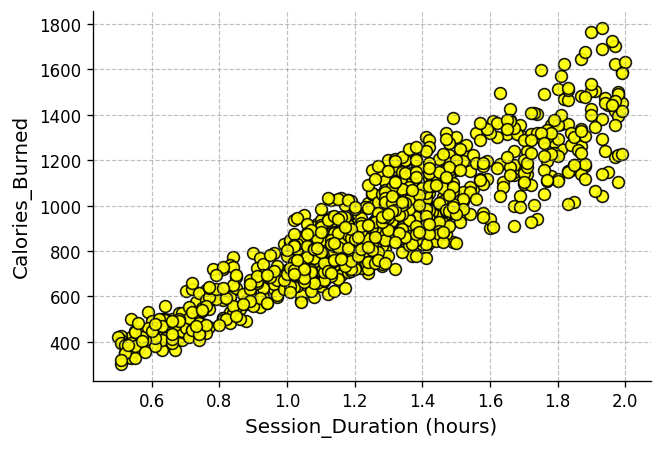

In [58]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='yellow',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Session_Duration (hours)', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Calories_Burned', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

El gráfico de disperción muestra una clara tendencia lineal positiva. Conforme aumentan las calorias quemadas, tambien aumenta la duracion de la secion de ejercicio.

**2.-¿Cuál fue el valor del coeficiente de correlación y cómo se interpreta?**

In [59]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.9081
valor_p:  0.0000


El coeficiente de correlación $r=0.9081$ indica una correlación lineal positiva y mas fuerte , sin embargo, se rechaza la hipotesis nula y se concluye que si existe correlacion lineal entre las variables.

**3.-¿Cuál fue el coeficiente de determinación y qué porcentaje de la variabilidad explica el modelo?**

In [60]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [61]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  82.47%


**4.-¿Cuál es la ecuación de regresión obtenida?**

**$R^2=0.8247$**

**5.-¿Qué significa la pendiente en el contexto del gimnasio?**

Una vez ajustado el modelo de regresión lienal, se obtiene un coeficiente calorico de $R^2=0.8247$. Entonces teniendo las horas de secion y el modelo ajustado, sólo podemos justificar la variabilidad en las calorias quemadas en un 82.47%, lo que es muy alto que fue considerado un ajuste fuertey positivo para los GYM RATS

La ecuación de la recta es:

$$
\hat{y}=-1.446459+721.786016X
$$

Este modelo estima que, la calificación base ($X=0$) es de aproximadamente $1.44$. Lo que significa que si un estudiante no estudia, se espera que obtenga un índice de desempeño con ese valor. Mientras que una pendiente de 721.78, indica que por cada hora estudiada se espera un aumento en la calificación de aproximadamente 721.78.


**6.-¿Qué indican los residuales sobre la calidad del modelo?**

In [62]:
import pandas as pd
import statsmodels.api as sm

# Load the dataframe
df = pd.read_csv("https://raw.githubusercontent.com/rubendariodiazvitals-crypto/EstadisticaVerano2026/refs/heads/main/Gym_Members/gym_members_exercise_tracking-selected-columns%20(2).csv")

# Define X and Y variables
Y = df["Calories_Burned"]      # Variable dependiente (originally independent in comment, but dependent in code)
X = df["Session_Duration (hours)"]    # Variable independiente (originally dependent in comment, but independent in code)

# Add a constant to the independent variable
x_constante = sm.add_constant(X)

# Create and fit the OLS model
modelo = sm.OLS(Y, x_constante).fit()

# Print the model parameters
modelo.params

,0
const,-1.446459
Session_Duration (hours),721.786016


**7.-¿Qué estimación o predicción se obtuvo con el modelo?**

La ecuación de la recta es:

$$
\hat{y}=-1.446459+721.786016X
$$

Este modelo estima que la constancia que fue:-1.446459 por lo que el valor esperado de la duración de la sesión es 0 y que Session_Duration (hours) es 721.786016 lo que indica que por cada hora adicional de la duración de la sesión

**CONCLUSIONES**

**1.-¿Qué hallazgos principales se obtuvieron?**

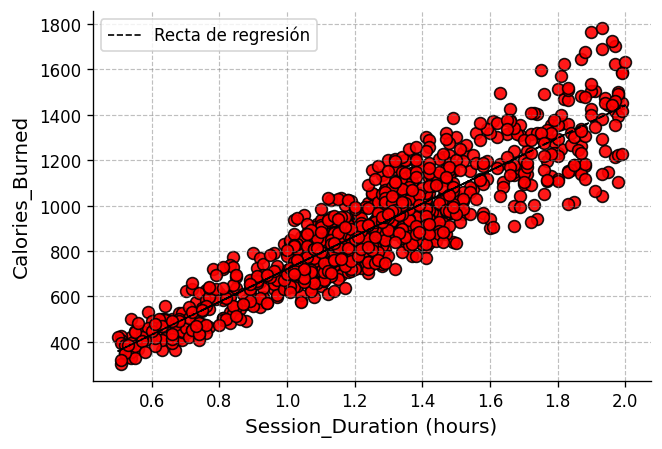

In [63]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='red',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Session_Duration (hours)', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Calories_Burned', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    loc='best',
    fontsize=10
)

Por lo que podemos ver en la grafica hay una relacion directa y clara, ya que a medida que aumenta el tiempo en la sesion, aumentaran las calorias quemadas.

**2.-¿La variable independiente permite explicar adecuadamente la variable dependiente?**

Si, ya que con el contexto gimnasio sabemos identificar que mientras mas calorias quememos, eso significa que hemos entrenado por mas horas o que nuestra sesion son mas extensas

**3.-¿Qué tan confiable es el modelo construido?**

In [64]:
modelo.conf_int(alpha=0.05)

,0,1
const,-28.738459,25.845542
Session_Duration (hours),700.830270,742.741762


Este modelo muestra un nivel de confianza del 95% de confianza. Ademas de que el intervalo va de $-28.73$ a $25.84$ y con una variable que va de $700.83$ a $742.74$

Lo cual indica que la duracion de la sesion tiene un efecto real y medible en el modelo

**4.-¿Qué limitaciones tiene el análisis?**

In [65]:
residuales = modelo.resid

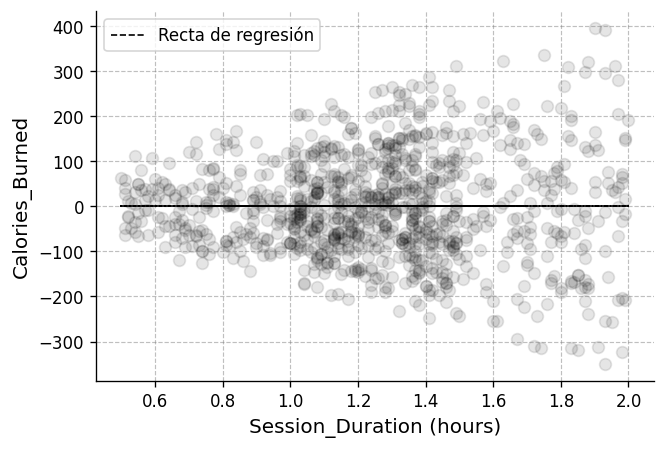

In [66]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, residuales,      # <-----------------
    marker="o",       # forma: googlear "matplotlib.markers"
    color='black',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.1,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada * 0,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Session_Duration (hours)', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Calories_Burned', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)

Como vemos el eje de calorias tiene valores negativos $(-300 a 300)$  .Por lo que sigiere que el grafico muestra residuos o los datos estandarizados, ya que no se pueden quemar calorias

. Además, los datos parecen no cumplir cavalmente con la homoscedasticidad. Sin embargo, pese a lo que se observa, se realizarán las pruebas estadísticas.

**5.-¿Qué recomendación general se le daría al gimnasio?**

valor-p (Shapiro) = 0.003841645423152361


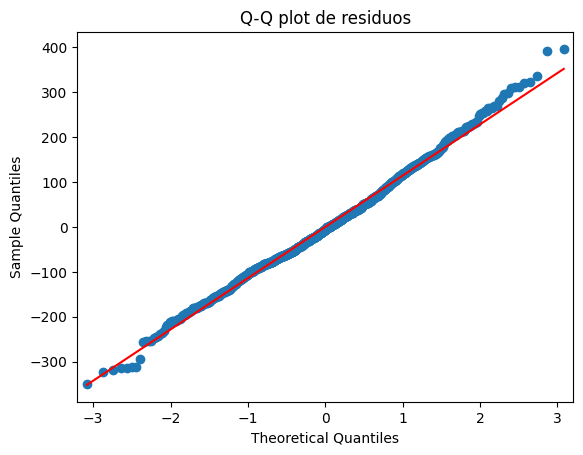

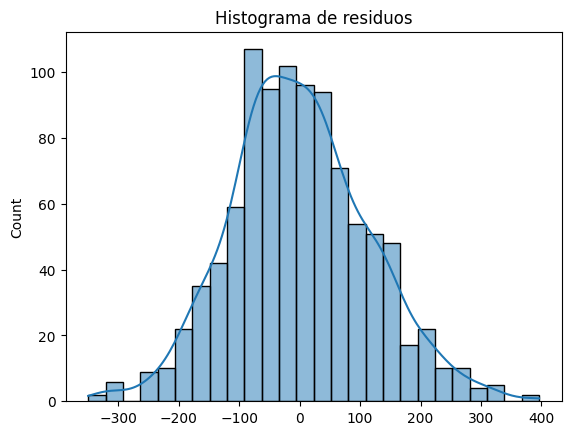

In [67]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# n < 30, Shapiro-Wilk es el más confiable
# n >= 30, Histograma o Q-Q plot

# test de Shapiro-Wilk
1
# H0: Hay normalidad    0.4172971767713699
0.05
# H1: No hay normalidad
0

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

Como recomendación es que van muy bien con el desgaste calórico pero sería mejor darle un poco más de calidad, aunque sea por más tiempo pero con calidad en el ejercicio

**6.-¿Conviene usar sólo esta variable o sería mejor considerar otras variables adicionales?**

In [68]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.0000



El hecho de que exista heterocedasticidad sugiere que la variable actual no es suficiente para explicar y lo mejor sera incluir mas variables para capturar mejor varibilidad de los datos

In [69]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Y ~ X
modelo_lineal = ols('Calories_Burned ~ Q("Session_Duration (hours)")', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
"Q(""Session_Duration (hours)"")",1.0,5.958764e+07,5.958764e+07,4568.674447,0.0
Residual,971.0,1.266442e+07,1.304265e+04,NaN,NaN


In [70]:
df


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type
0,56,Male,88.3,1.71,180,157,60,1.69,1313,Yoga
1,46,Female,74.9,1.53,179,151,66,1.30,883,HIIT
2,32,Female,68.1,1.66,167,122,54,1.11,677,Cardio
3,25,Male,53.2,1.70,190,164,56,0.59,532,Strength
4,38,Male,46.1,1.79,188,158,68,0.64,556,Strength
...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364,Strength
969,25,Male,66.6,1.61,184,166,56,1.38,1260,Strength
970,59,Female,60.4,1.76,194,120,53,1.72,929,Cardio
971,32,Male,126.4,1.83,198,146,62,1.10,883,HIIT
